<a href="https://colab.research.google.com/github/AminKJun/ARMEEN/blob/main/predictive%20data%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS5805 Coursework PDA
1916721

15 April, 2024


0. Instructions

Importing all the appropriate librabries.

In [ ]:
import pandas as pd #Library for data manipulation and analysis
import numpy as np #Provides support for multi-dimensional arrays and matrices, along with a collection
                   #of mathematical functions to operate on these arrays efficiently
import matplotlib.pyplot as plt #plotting library for Python, and pyplot is a collection
                                #of command-style functions that make Matplotlib work like MATLAB
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier



Loading the Loan Prediction data

In [ ]:
#The data from the CSV file is loaded into the DataFrame loan_approval
loan_approval = pd.read_csv('loan_approval_dataset.csv')
# Display the original column names
print("Original Column Names:")
print(loan_approval.columns)

# Remove spaces from column names as noticed in the original data
loan_approval.columns = loan_approval.columns.str.replace(' ', '')

# Display the updated column names without
print("\nUpdated Column Names:")
print(loan_approval.columns)

Original Column Names:
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

Updated Column Names:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')




```
# This is formatted as code
```

###Data Cleaning
In this stage we will look for any missing values, invalid entries, etc.

In [ ]:
loan_approval.head()  # Checking the first 6 rows of the dataset

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
#The values in these categorical variables had an extra space as identified above and from CSV file.
# List of categorical columns
categorical_columns = ['education', 'self_employed', 'loan_status']

# Remove leading and trailing spaces from categorical column values
for col in categorical_columns:
    loan_approval[col] = loan_approval[col].str.strip()

# Check the first few rows to verify changes
print(loan_approval.head())

   loan_id  no_of_dependents     education self_employed  income_annum  \
0        1                 2      Graduate            No       9600000   
1        2                 0  Not Graduate           Yes       4100000   
2        3                 3      Graduate            No       9100000   
3        4                 3      Graduate            No       8200000   
4        5                 5  Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000           8000000 

In [ ]:
# Getting information about the dataset which includes count information, non-null values and data type
loan_approval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
#Looking for missing values in the dataset
loan_approval.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [ ]:
#Returns the number of unique elements in each column of the DataFrame
loan_approval.nunique()


loan_id                     4269
no_of_dependents               6
education                      2
self_employed                  2
income_annum                  98
loan_amount                  378
loan_term                     10
cibil_score                  601
residential_assets_value     278
commercial_assets_value      188
luxury_assets_value          379
bank_asset_value             146
loan_status                    2
dtype: int64

In [ ]:
#returns a Series object that contains the count of each unique value in the 'loan_status'
loan_approval['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [ ]:
# Filter out the rows with negative loan amounts
loan_approval = loan_approval[loan_approval['residential_assets_value'] >= 0]

In [ ]:
#Identifying the mean, IQR, Standard Deviation and other parameters.
loan_approval.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4241.0,2.134503e+03,1.231650e+03,1.0,1068.0,2137.0,3201.0,4269.0
no_of_dependents,4241.0,2.497996e+00,1.695599e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4241.0,5.074251e+06,2.803166e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4241.0,1.517840e+07,9.034490e+06,300000.0,7700000.0,14600000.0,21500000.0,39500000.0
loan_term,4241.0,1.090215e+01,5.708988e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4241.0,5.996857e+02,1.722773e+02,300.0,453.0,600.0,747.0,900.0
residential_assets_value,4241.0,7.522613e+06,6.495800e+06,0.0,2200000.0,5700000.0,11400000.0,29100000.0
commercial_assets_value,4241.0,4.985121e+06,4.391504e+06,0.0,1300000.0,3700000.0,7700000.0,19400000.0
luxury_assets_value,4241.0,1.517121e+07,9.094717e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4241.0,4.991488e+06,3.249494e+06,0.0,2400000.0,4600000.0,7100000.0,14700000.0


**Exploratory Data Analysis**\

Statistical Analysis

In [ ]:
#For Categorical Variables
#Null Hypotheses: There is no significant relation between Loan Status & Categorical Variables
#Alternate Hypotheses: There is significant relation between Loan Status & Categorical Variables


#Chi-Squared test for 'loan_status' and 'education'(Code from GenAI)

contingency_table = pd.crosstab(loan_approval['loan_status'], loan_approval['education'])
chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)

# Print results
print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)

#Chi-Squared test for 'loan_status' and 'self_employed'(Code from GenAI)

contingency_table = pd.crosstab(loan_approval['loan_status'], loan_approval['self_employed'])
chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
3
# Print results
print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)

Chi-square statistic: 0.07961510675413244
P-value: 0.7778196851434889
Chi-square statistic: 0.009348907992318503
P-value: 0.9229727790303127


   loan_id  no_of_dependents education self_employed  income_annum  \
0        1                 2  Graduate            No       9600000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value  \
0                 17600000             22700000           8000000   

   loan_status_Approved  loan_status_Rejected  
0                   1.0                   0.0  


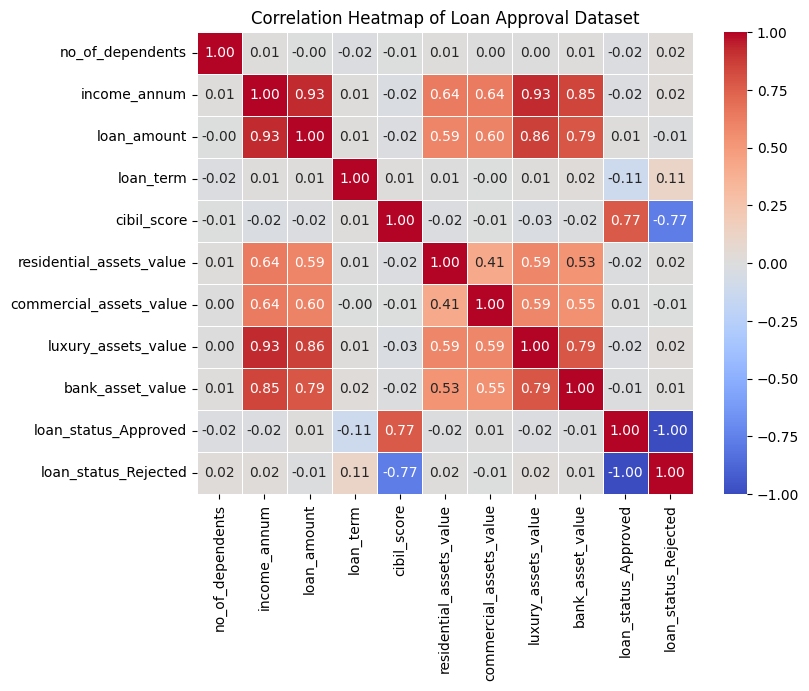

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# One-hot encode the 'loan_status' column
loan_approval_encoded = pd.get_dummies(loan_approval, columns=['loan_status'],dtype=float)
print(loan_approval_encoded.head(1))

# selecting relevant columns for correlation analysis
selected_columns = ['no_of_dependents',  'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
                    'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status_Approved', 'loan_status_Rejected']

# Calculate the correlation matrix
correlation_matrix = loan_approval_encoded[selected_columns].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Loan Approval Dataset')
plt.show()

The correlation heatmap indicates strong positive correlations between 'loan_amount' and 'income_annum', suggesting that individuals with higher annual incomes tend to apply for larger loan amounts.

In [ ]:
pip install --upgrade plotly

EDA Visualization (Univariate)

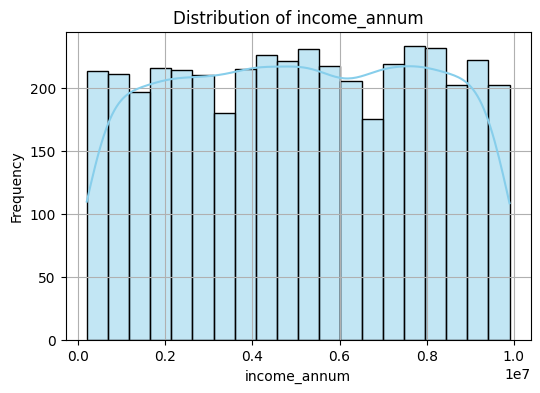

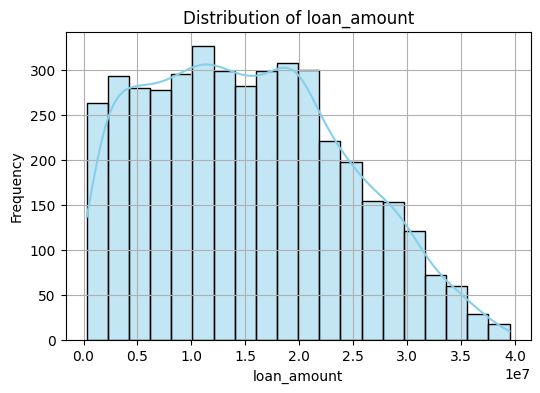

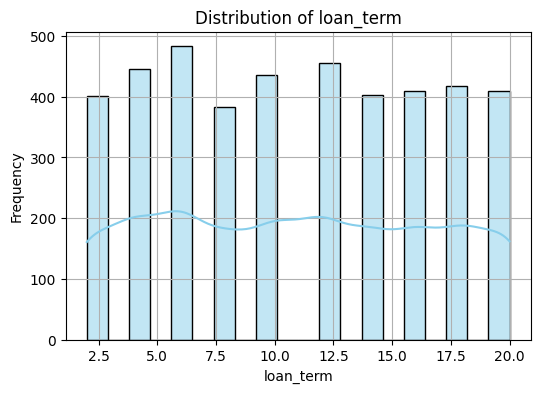

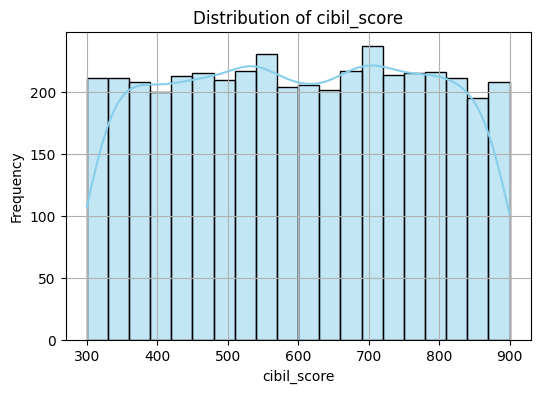

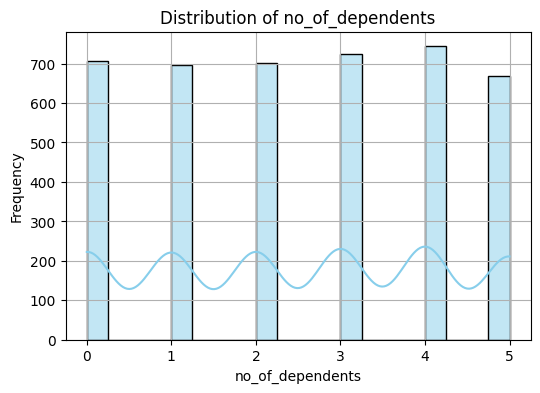

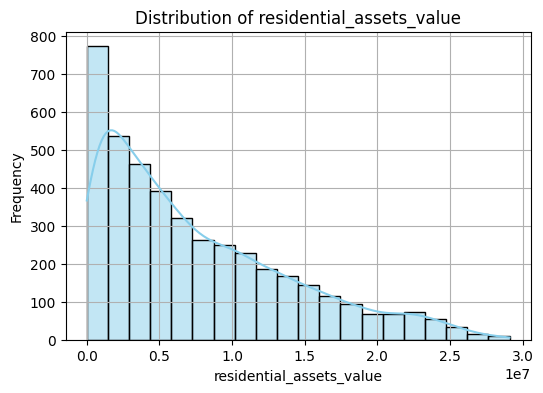

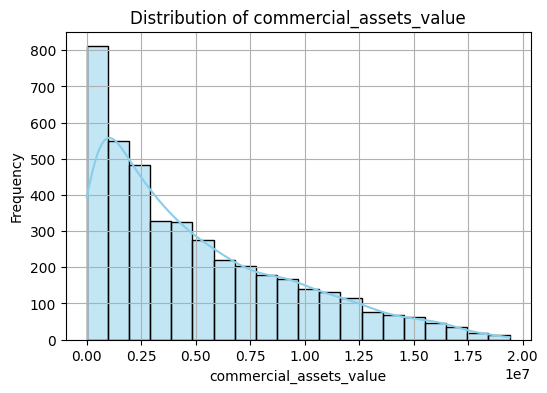

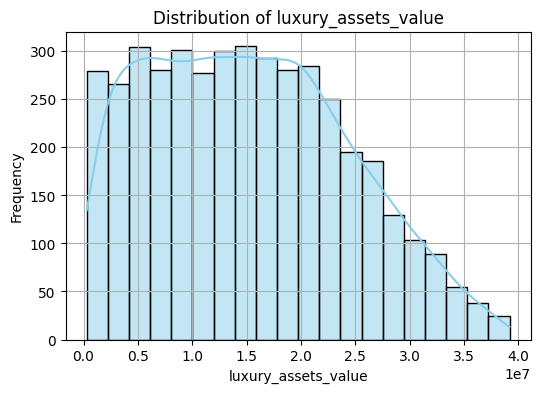

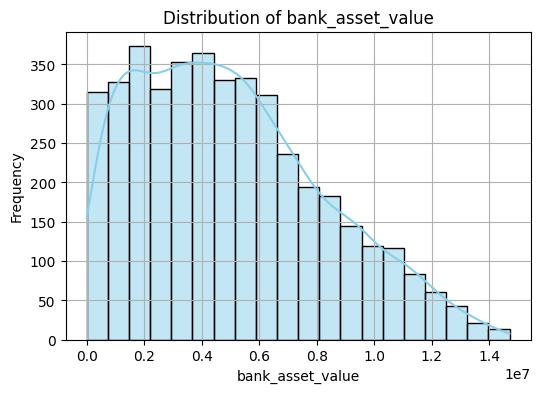

In [ ]:
# Defining the columns to be checked for normal distribution
numerical_columns = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'no_of_dependents', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

# Checking for normal distribution of numerical independent variables like income_annum, loan_amount and cibil_score
for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(loan_approval[column], bins=20, color='skyblue', edgecolor='black', kde=True)
    plt.title('Distribution of ' + column)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)  # Add grid for better readability
    plt.show()

Analysing the numerical variable- LOAN_AMOUNT using q-q plot

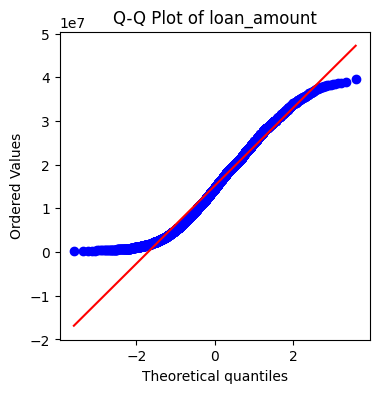

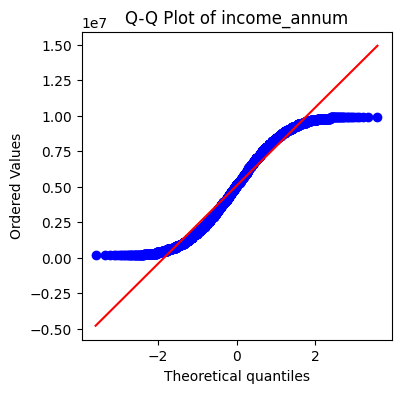

In [ ]:
numerical_column = 'loan_amount'
from scipy import stats

# 1. Q-Q Plot
plt.figure(figsize=(4, 4))
stats.probplot(loan_approval[numerical_column], dist="norm", plot=plt)
plt.title('Q-Q Plot of ' + numerical_column)
plt.show()



numerical_column1 = 'income_annum'
from scipy import stats

# 1. Q-Q Plot
plt.figure(figsize=(4, 4))
stats.probplot(loan_approval[numerical_column1], dist="norm", plot=plt)
plt.title('Q-Q Plot of ' + numerical_column1)
plt.show()

EDA (Multivariate)

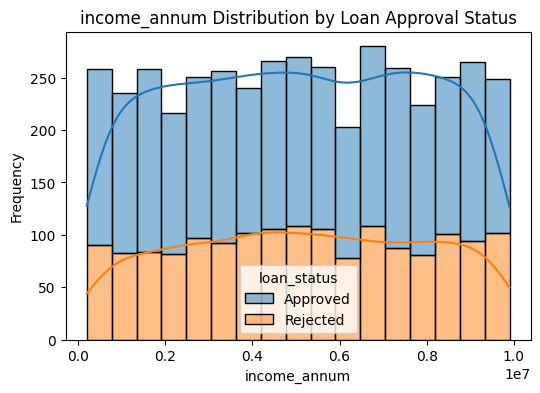

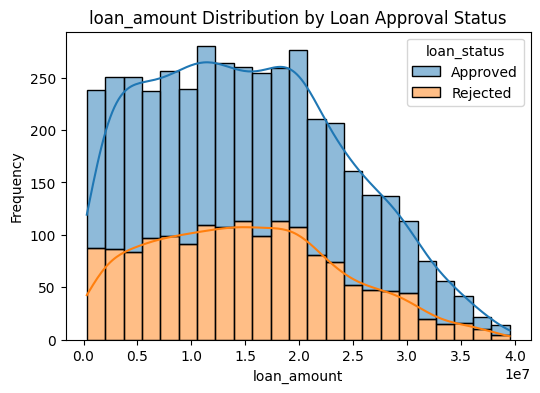

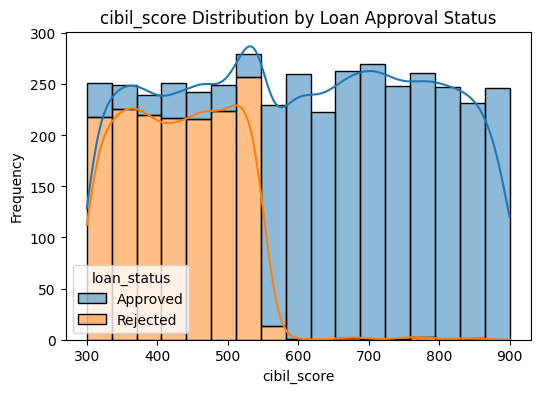

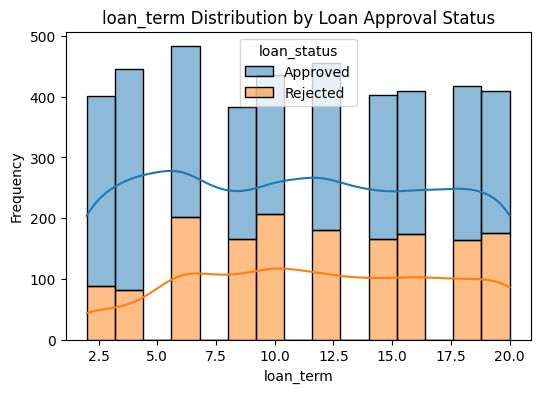

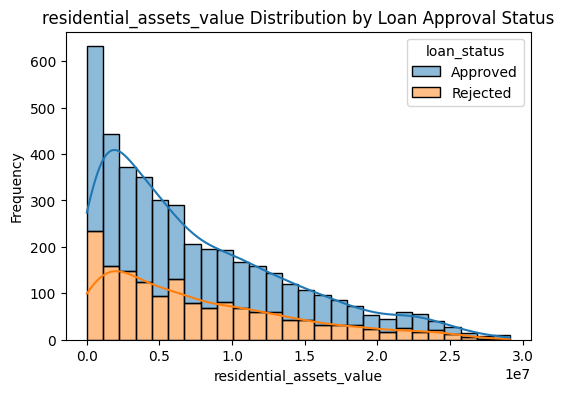

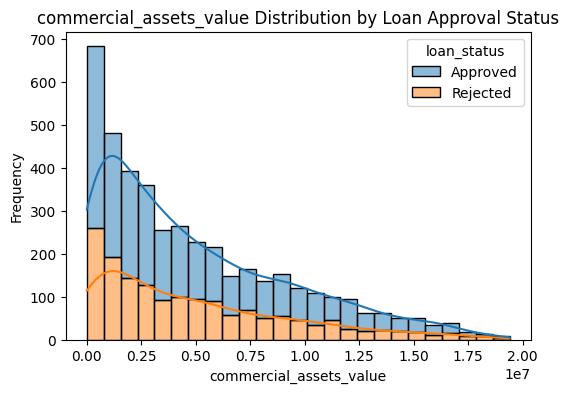

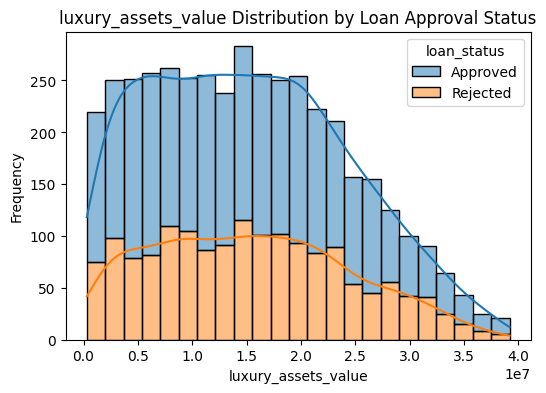

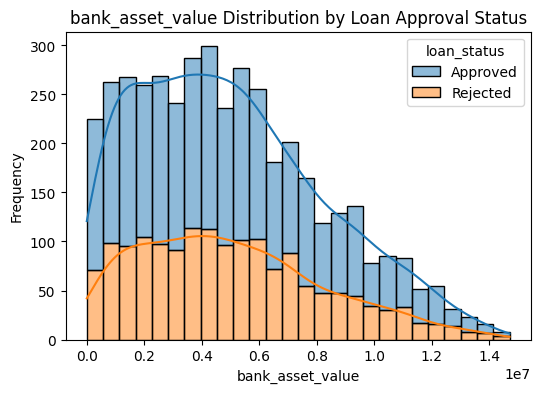

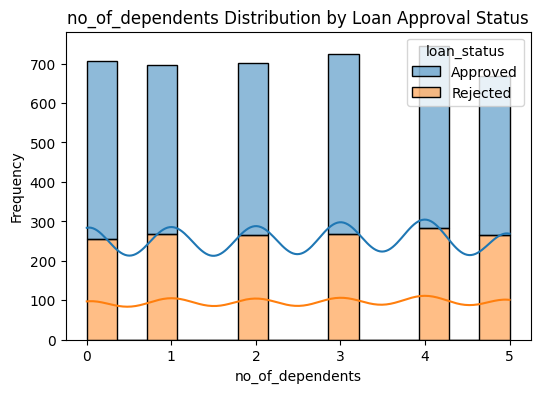

In [ ]:
# Numerical features vs. Target variable
numerical_features = ['income_annum', 'loan_amount', 'cibil_score', 'loan_term', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'no_of_dependents']

for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(x=feature, hue='loan_status', data=loan_approval, kde=True, multiple='stack')
    plt.title(f'{feature} Distribution by Loan Approval Status')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

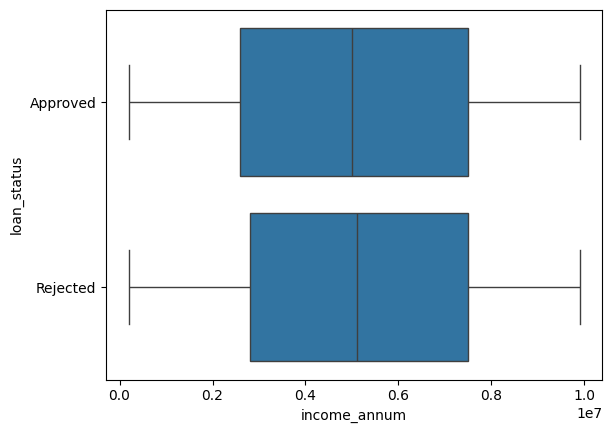

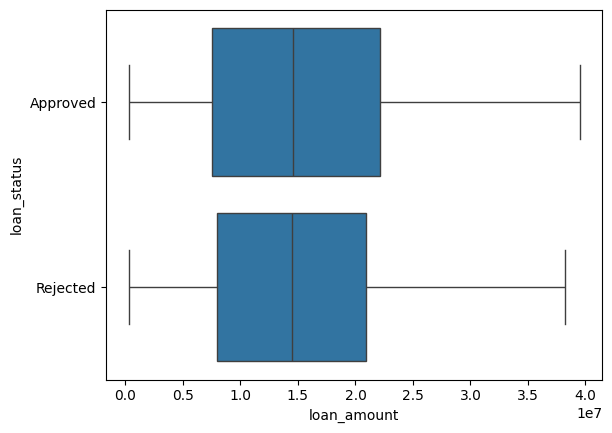

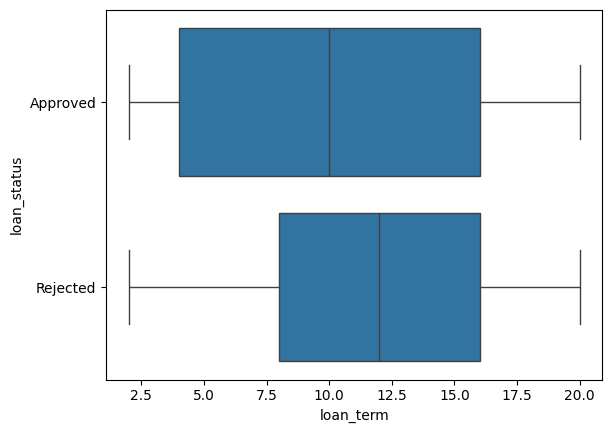

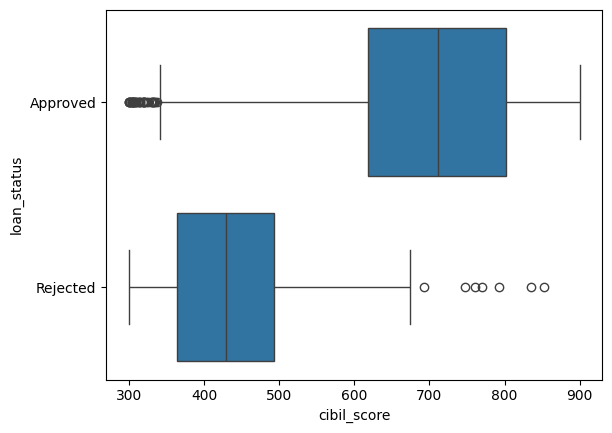

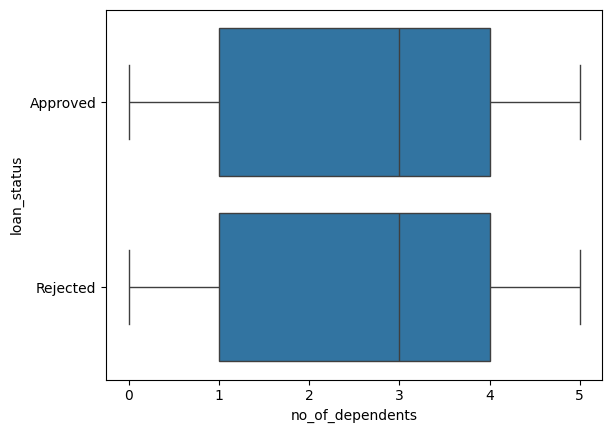

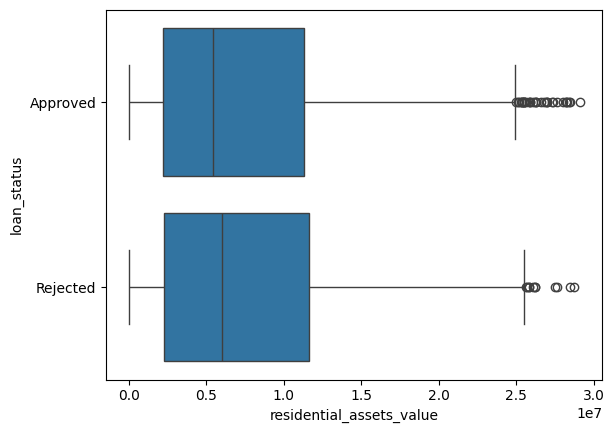

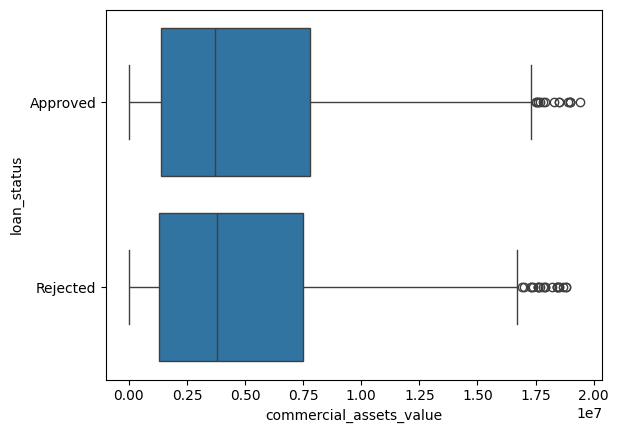

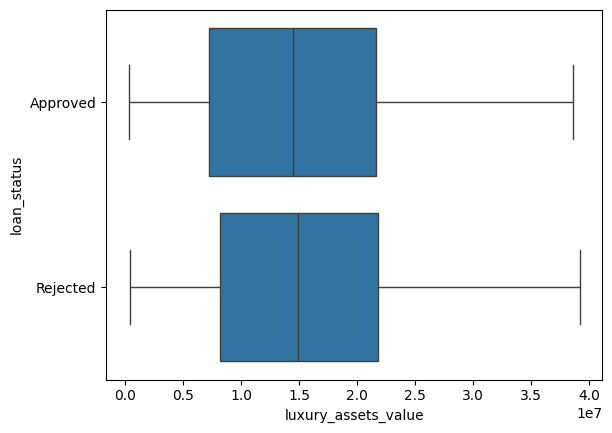

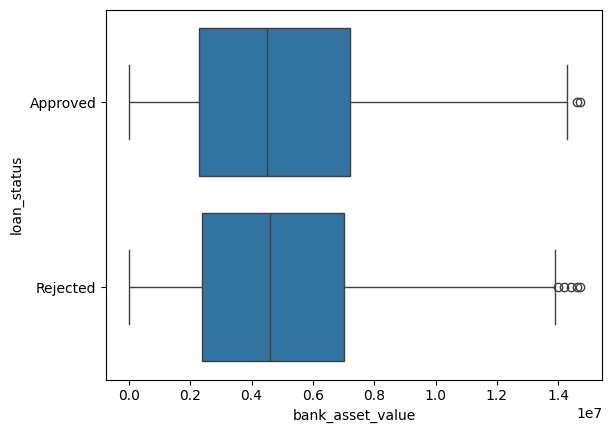

In [ ]:
sns.boxplot(data=loan_approval, x="income_annum", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="loan_amount", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="loan_term", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="cibil_score", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="no_of_dependents", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="residential_assets_value", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="commercial_assets_value", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="luxury_assets_value", y="loan_status")
plt.show()
sns.boxplot(data=loan_approval, x="bank_asset_value", y="loan_status")
plt.show()

In [ ]:
import plotly.express as px

# Categorical features
categorical_features = ['education', 'self_employed']

for feature in categorical_features:
    fig = px.histogram(loan_approval, x=feature, color='loan_status', barmode='group')
    fig.update_layout(title=f'Distribution of {feature} by Loan Status')
    fig.show()

PCA

In [ ]:
# Define features and target variable(Code by GenAI)
features = ['income_annum', 'loan_amount', 'cibil_score', 'loan_term',
            'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
target = 'loan_status'

# Split the data into features (X) and target variable (y)
X = loan_approval[features]
y = loan_approval[target]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=6)  # Choose the number of components to keep
X_pca = pca.fit_transform(X_scaled)

# Calculate the proportion of variance explained by each principal component
explained_variance_ratio = pca.explained_variance_ratio_

# Sum of the proportions to get the total percentage of variance explained
total_variance_ratio = np.sum(explained_variance_ratio)

# Convert to percentage
total_variance_percentage = total_variance_ratio * 100

print("Total variance explained by all principal components: {:.2f}%".format(total_variance_percentage))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


Total variance explained by all principal components: 97.72%


In [ ]:
import matplotlib.pyplot as plt

# Plotting the explained variance by each principal component after PCA
plt.figure(figsize=(10, 6))
plt.bar(range(1, 10), pca.explained_variance_ratio_, alpha=0.6, color='g', label='Individual explained variance')
plt.step(range(1, 10), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Explained Variance by Each Principal Component')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.legend(loc='best')
plt.show()


AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(X_pca)

[[ 2.90691107 -0.87433944  0.73701639  2.53344212 -0.36871141 -0.31048118]
 [-1.28409598  1.10625171 -0.4278773   0.12564372  0.36477954 -0.09710912]
 [ 3.20066993 -0.79757348 -1.50239723  0.18578221  1.93294574  0.39900054]
 ...
 [ 1.36087333 -0.32746475 -1.38148059  1.9336142  -0.03646968  0.03584717]
 [-0.53779469 -0.36844447  1.06202043 -0.74039805  0.57016226  0.34627842]
 [ 4.33132056  0.0628144   0.19810071 -0.03442285 -0.06212301  0.37695119]]


Models


# Machine learning model KNN


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

Accuracy: 0.928150765606596
Classification Report:
               precision    recall  f1-score   support

    Approved       0.94      0.95      0.94       543
    Rejected       0.90      0.90      0.90       306

    accuracy                           0.93       849
   macro avg       0.92      0.92      0.92       849
weighted avg       0.93      0.93      0.93       849

Confusion Matrix:
 [[514  29]
 [ 32 274]]


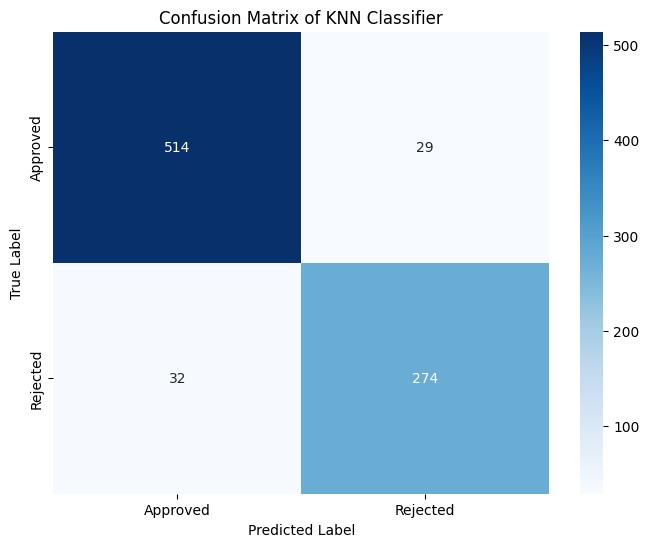

In [ ]:
# Create a transformer for numerical data
numeric_transformer = StandardScaler()

# Create a transformer for categorical data
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Confusion Matrix and Classification Report
conf_matrix = confusion_matrix(y_test, y_pred)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_rep)
print("Confusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of KNN Classifier')
plt.show()
